In [37]:
##LIBRERIAS##
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [38]:
##CARGA DE DATOS## 
def leer_columnas(path_archivo):
    columnas = []

    with open(Path(path_archivo), "r", encoding="latin-1", errors="ignore") as f:
        for linea in f:
            partes = linea.strip().replace(",", ".").split()
            try:
                fila = [float(x) for x in partes]
                
                if not columnas:
                    columnas = [[] for _ in range(len(fila))]
           
                for i, val in enumerate(fila):
                    columnas[i].append(val)
            except ValueError:
                
                continue

    return np.array(columnas)

In [39]:
##GRAFICA Y AJUSTE##
def plot_ajuste(x, z, y,err_z, err_y, err_x, tittle, x_tittle, y_tittle,z_ajuste, 
                x_ajuste, y_ajuste, residuales_norm1, residuales_norm2, z_legend = "D2", y_legend = "D1",
                color_n1="#D6259B", color_n2="#51D63F"):

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 14), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )
    
    # --- Gráfico principal ---
    ax1.set_title(tittle, fontsize=22, weight="bold")
    ax1.set_ylabel(x_tittle, fontsize=20)
    ax1.tick_params(axis="both", labelsize=20, width=2)  # ticks más grandes y gruesos
    ax1.grid(True, alpha=0.3)

    # Ejes más gruesos
    for spine in ax1.spines.values():
        spine.set_linewidth(2)

    ax1.errorbar(
        x, y, xerr=err_x, yerr=err_y,
        fmt="v", markersize=10, mfc=color_n1, mec="black",
        elinewidth=2, capthick=2, color=color_n1,
        label= y_legend + " con error"
    )
    ax1.errorbar(
        x, z, xerr=err_x, yerr=err_z,
        fmt="o", markersize=10, mfc=color_n2, mec="black",
        elinewidth=2, capthick=2, color=color_n2,
        label= z_legend + " con error"
    )   

    ax1.plot(x_ajuste, y_ajuste, "--", linewidth=3,
             color="black", label="Línea de ajuste")
    ax1.plot(x_ajuste, z_ajuste, "--", linewidth=3,
             color="gray", label="Línea de ajuste")
    ax1.legend(fontsize=16)

    # --- Gráfico de residuales ---
    ax2.set_xlabel(y_tittle, fontsize=20)
    ax2.set_ylabel("Residuales\n(normalizados)", fontsize=20)
    ax2.tick_params(axis="both", labelsize=20, width=2)
    ax2.axhline(0, color='gray', linestyle='--', linewidth=2)

    for spine in ax2.spines.values():
        spine.set_linewidth(2)

    ax2.scatter(x, residuales_norm1, color=color_n2, s=90, edgecolor="black")
    ax2.scatter(x, residuales_norm2, color=color_n1, s=90, edgecolor="black")
    ax2.grid(True, alpha=0.3)
    ax1.set_xlim(0, max(x) + 0.01)
    plt.tight_layout()
    plt.show()


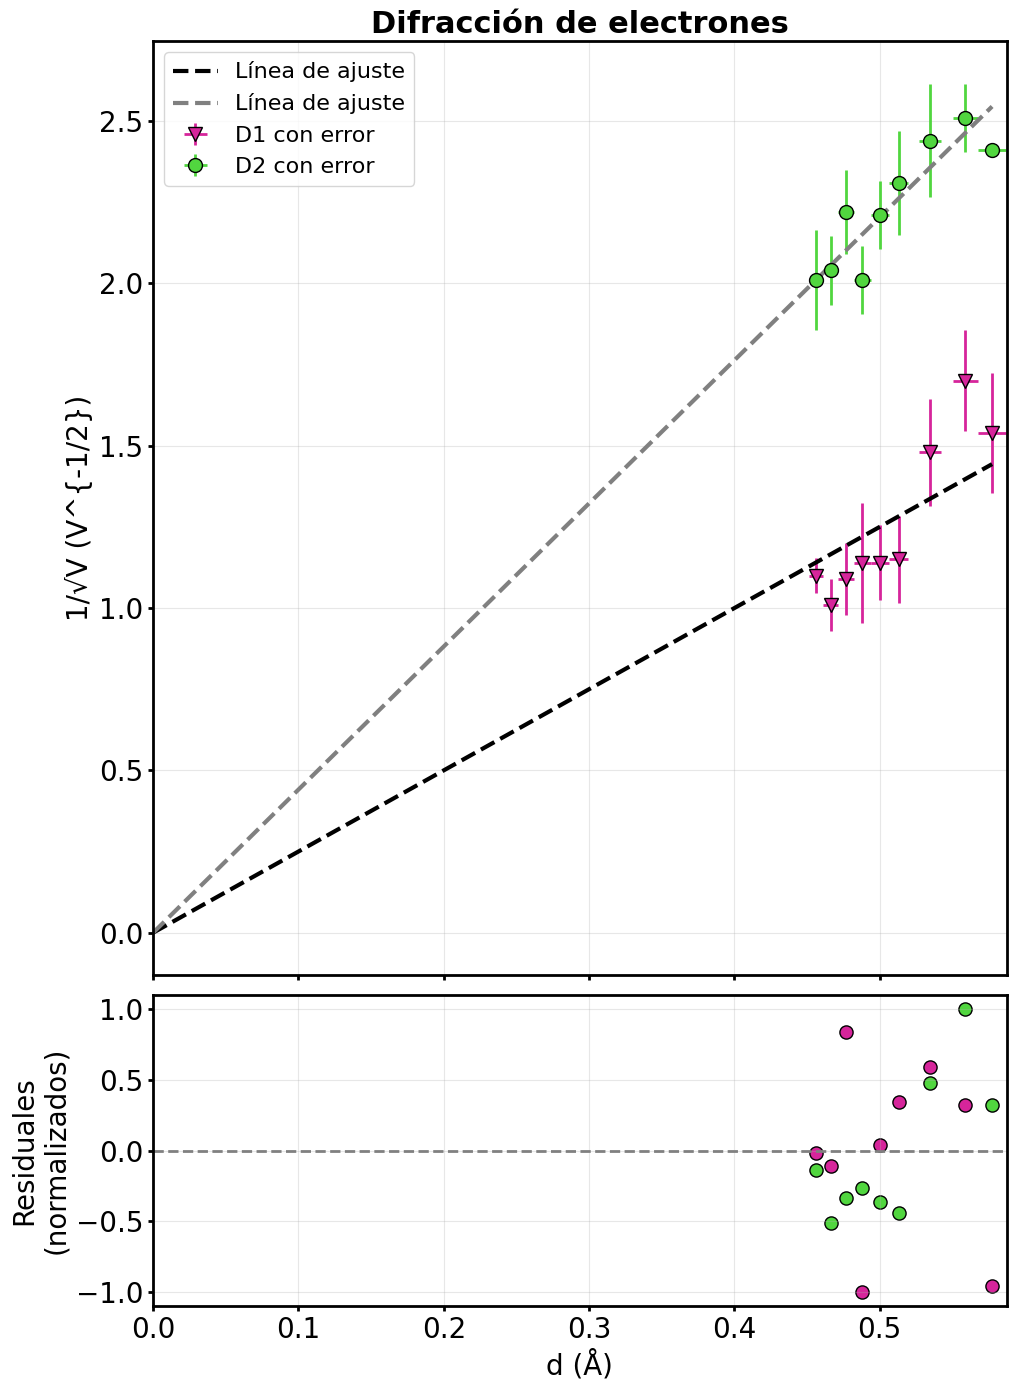

In [40]:
# --- CARGA Y PREPARACIÓN ---
archivo = "toma_de_Datos.txt"
archivo2 = "toma_de_datos_2.txt"
data = leer_columnas(archivo)
data2 = leer_columnas(archivo2)

x = 1 / (data[0]**(1/2))
err_x = 1 / (data[0]**(3/2)) * data[1] / 2
y = data2[2][:9]
err_y = (data2[3]/2)[:9]
z = data[4]
err_z = data[5]

# --- AJUSTE LINEAL FORZADO A ORIGEN (y vs x) ---
A = x.reshape(-1, 1)  # diseño sin columna de 1's -> ajuste sin intercepto
coef_y, *_ = np.linalg.lstsq(A, y, rcond=None)
mfit_y = float(coef_y[0])
bfit_y = 0.0

# incertidumbre de la pendiente (covarianza simplificada)
N = x.size
p = 1
y_pred = mfit_y * x
SSE_y = np.sum((y - y_pred)**2)
sigma2_y = SSE_y / (N - p) if N - p > 0 else 0.0
var_m_y = sigma2_y / np.sum(x**2) if np.sum(x**2) != 0 else 0.0
smfit_y = np.sqrt(var_m_y)
sbfit_y = 0.0

# Extender la línea de ajuste hasta x=0 para que toque (0,0)
x_ajuste = np.linspace(0, x.max(), 200)
y_ajuste = mfit_y * x_ajuste  # pasa por el origen

# residuales normalizados (y)
resid_y = y - (mfit_y * x + bfit_y)
max_abs_res_y = np.max(np.abs(resid_y))
if max_abs_res_y == 0:
    residuales_norm1 = np.zeros_like(resid_y)
    err_res_norm1 = np.zeros_like(err_y)
else:
    residuales_norm1 = resid_y / max_abs_res_y
    err_res_norm1 = err_y / max_abs_res_y

# --- AJUSTE LINEAL FORZADO A ORIGEN (z vs x) ---
coef_z, *_ = np.linalg.lstsq(A, z, rcond=None)
mfit_z = float(coef_z[0])
bfit_z = 0.0

z_pred = mfit_z * x
SSE_z = np.sum((z - z_pred)**2)
sigma2_z = SSE_z / (N - p) if N - p > 0 else 0.0
var_m_z = sigma2_z / np.sum(x**2) if np.sum(x**2) != 0 else 0.0
smfit_z = np.sqrt(var_m_z)
sbfit_z = 0.0

# extender también la línea de ajuste de z hasta x=0
z_ajuste = mfit_z * x_ajuste  # pasa por el origen

# residuales normalizados (z)
resid_z = z - (mfit_z * x + bfit_z)
max_abs_res_z = np.max(np.abs(resid_z))
if max_abs_res_z == 0:
    residuales_norm2 = np.zeros_like(resid_z)
    err_res_norm2 = np.zeros_like(err_z)
else:
    residuales_norm2 = resid_z / max_abs_res_z
    err_res_norm2 = err_z / max_abs_res_z

# --- PLOT ---
plot_ajuste(
    x, z, y, err_z, err_y, err_x,
    tittle="Difracción de electrones",
    x_tittle="1/√V (V^{-1/2})",
    y_tittle="d (Å)",
    z_ajuste=z_ajuste,
    x_ajuste=x_ajuste,
    y_ajuste=y_ajuste,
    residuales_norm1=residuales_norm1,
    residuales_norm2=residuales_norm2
)

In [41]:
from tabulate import tabulate
from scipy.constants import h, m_e, e
import numpy as np

# === Lectura de datos ===
V = leer_columnas(archivo)[0]  # Voltaje en kV
error_V = 0.1  # error instrumental en kV

# === Conversión a voltios ===
V_volt = V * 1e3
error_V_volt = error_V * 1e3

# === Cálculo de λ de Broglie en picómetros ===
lambda_broglie = (h / np.sqrt(2 * m_e * e * V_volt)) * 1e12  # [pm]
lambda_error = (h / (2 * np.sqrt(2 * m_e * e))) * (error_V_volt / (V_volt ** (3/2))) * 1e12  # [pm]

# === Datos de diámetros ===
pie_rey = 0.025  # cm
D1, bordes1 = leer_columnas(archivo)[2], leer_columnas(archivo)[3]
D2, bordes2 = leer_columnas(archivo)[4], leer_columnas(archivo)[5]

error_1 = np.sqrt(pie_rey**2 + bordes1**2)
error_2 = np.sqrt(pie_rey**2 + bordes2**2)

# === Cálculo de λ de Bragg en picómetros ===
L= 13.5 #Cm
D= D1 
n = 1 
lambda_bragg = D1*D2 / 2*L
lambda_bragg_error = np.sqrt((D2 * error_1/2*n*L)**(1/2) + (D1 * error_2/2*n*L)**(1/2) )

sigma_comb = np.sqrt(lambda_bragg_error**2 + lambda_error**2)  # pm
# Evitar división por cero:
sigma_comb = np.where(sigma_comb == 0, np.nan, sigma_comb)
z_sigma = (lambda_bragg - lambda_broglie) / sigma_comb
z_abs = np.abs(z_sigma)


### PRECISION 
avg_precision_D1 = (lambda_bragg_error/ lambda_bragg)*100
avg_precision_D2 = (lambda_error / lambda_broglie)*100

# (Opcional) Etiqueta simple según umbrales
def etiqueta_sigmas(z):
    if np.isnan(z): return "—"
    if z_abs_i := abs(z) < 1:  return "<1σ"
    if z_abs_i < 2:            return "1–2σ"
    if z_abs_i < 3:            return "2–3σ"
    return "≥3σ"

labels = [etiqueta_sigmas(z) for z in z_abs]

# === Tabla ===
data = []
for i in range(len(V)):
    data.append([
        V[i], D1[i], error_1[i],
        D2[i], error_2[i],
        lambda_broglie[i], lambda_error[i],
        lambda_bragg[i],  lambda_bragg_error[i],
        z_sigma[i], z_abs[i], labels[i], avg_precision_D1[i], avg_precision_D2[i]
    ])

print(tabulate(
    data,
    headers=[
        "V (kV)", "d (cm)", "σ_d (cm)", "D (cm)", "σ_D (cm)",
        "λ_deB (pm)", "σ_λ_deB (pm)", "λ_Bragg (pm)", "σ_λ_B (pm)",
        "z (σ)", "|z|", "Etiqueta"," Precisión %", "Precisión %"
    ],
    floatfmt=(".2f")
))


  V (kV)    d (cm)    σ_d (cm)    D (cm)    σ_D (cm)    λ_deB (pm)    σ_λ_deB (pm)    λ_Bragg (pm)    σ_λ_B (pm)    z (σ)    |z|  Etiqueta       Precisión %    Precisión %
--------  --------  ----------  --------  ----------  ------------  --------------  --------------  ------------  -------  -----  ----------  --------------  -------------
    3.00      1.61        0.03      2.41        0.03         22.39            0.37           26.19          1.10     3.26   3.26  1–2σ                  4.21           1.67
    3.20      1.07        0.03      2.51        0.11         21.68            0.34           18.13          1.25    -2.75   2.75  1–2σ                  6.89           1.56
    3.50      1.33        0.12      2.44        0.18         20.73            0.30           21.91          1.63     0.71   0.71  <1σ                   7.45           1.43
    3.80      1.32        0.07      2.31        0.16         19.90            0.26           20.58          1.50     0.45   0.45  <1σ       

## Tercera toma datos


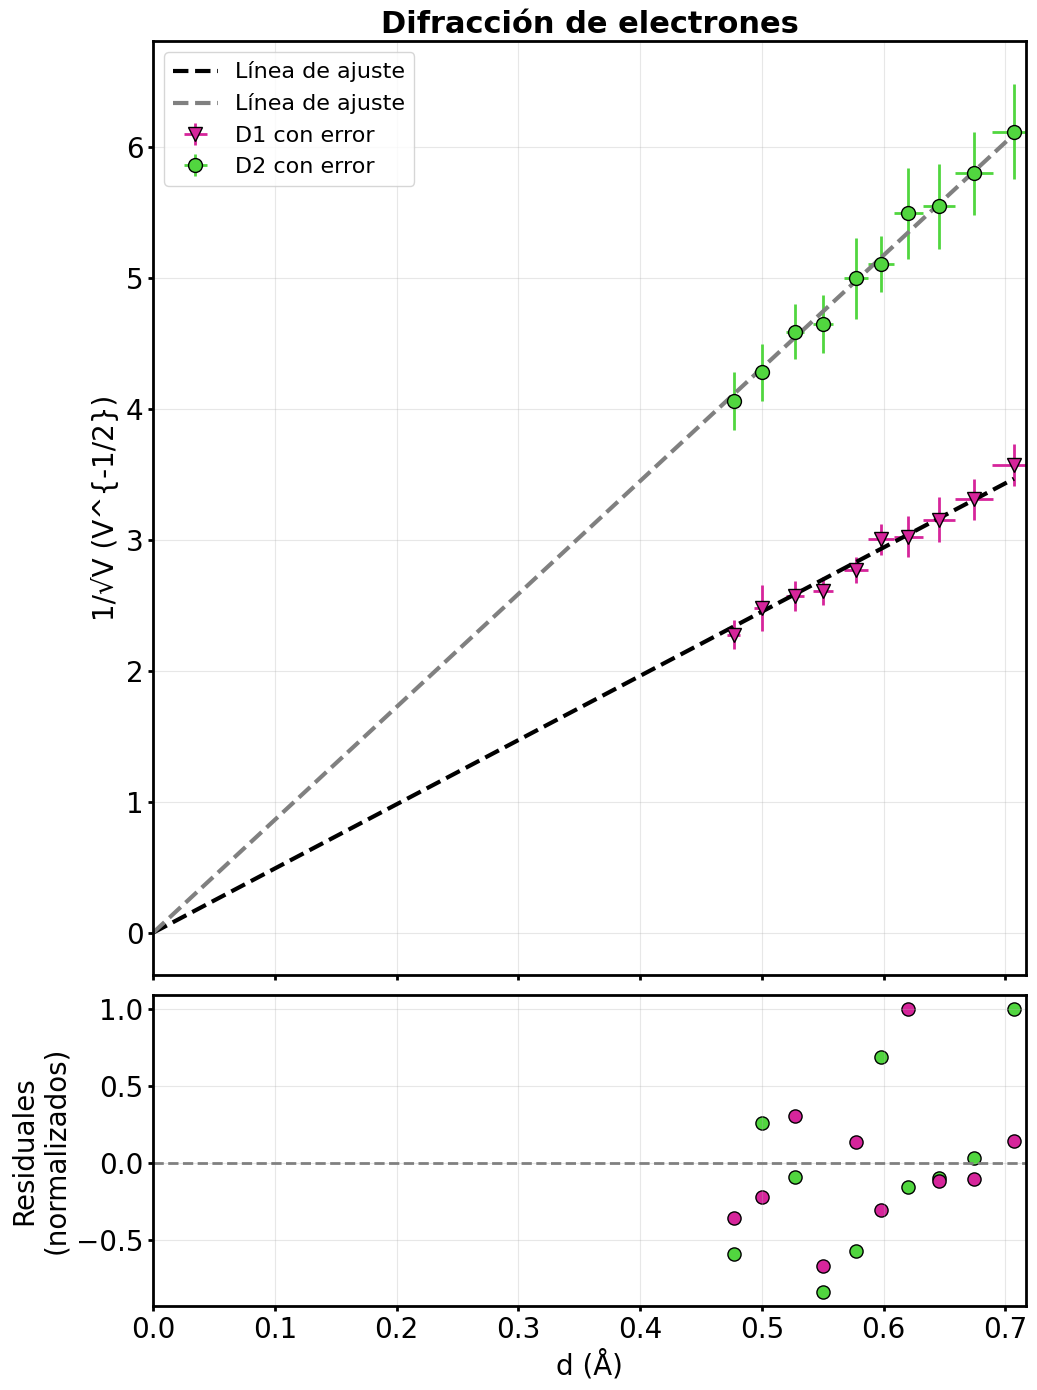

In [42]:
# --- CARGA Y PREPARACIÓN ---
archivo2 = "toma_de_datos_3.txt"
data2 = leer_columnas(archivo2)

# Variables desde el archivo 2
x = 1 / np.sqrt(data2[0])              # 1 / √V
err_x = data2[1] / (2 * data2[0]**(3/2))  # propagación de error

y = data2[2]                           # columna d (Å)
err_y = data2[3] / 2                   # error asociado a d

z = data2[4]                           # si hay una segunda serie de datos (por ejemplo, otro anillo)
err_z = data2[5]

# --- AJUSTE LINEAL FORZADO A ORIGEN (y vs x) ---
A = x.reshape(-1, 1)  # diseño sin intercepto
coef_y, *_ = np.linalg.lstsq(A, y, rcond=None)
mfit_y = float(coef_y[0])
bfit_y = 0.0

# incertidumbre de la pendiente (covarianza simplificada)
N = x.size
p = 1
y_pred = mfit_y * x
SSE_y = np.sum((y - y_pred)**2)
sigma2_y = SSE_y / (N - p) if N - p > 0 else 0.0
var_m_y = sigma2_y / np.sum(x**2) if np.sum(x**2) != 0 else 0.0
smfit_y = np.sqrt(var_m_y)
sbfit_y = 0.0

# Extender línea de ajuste hasta x=0
x_ajuste = np.linspace(0, x.max(), 200)
y_ajuste = mfit_y * x_ajuste  # pasa por el origen

# residuales normalizados (y)
resid_y = y - (mfit_y * x + bfit_y)
max_abs_res_y = np.max(np.abs(resid_y))
if max_abs_res_y == 0:
    residuales_norm1 = np.zeros_like(resid_y)
    err_res_norm1 = np.zeros_like(err_y)
else:
    residuales_norm1 = resid_y / max_abs_res_y
    err_res_norm1 = err_y / max_abs_res_y

# --- AJUSTE LINEAL FORZADO A ORIGEN (z vs x) ---
coef_z, *_ = np.linalg.lstsq(A, z, rcond=None)
mfit_z = float(coef_z[0])
bfit_z = 0.0

z_pred = mfit_z * x
SSE_z = np.sum((z - z_pred)**2)
sigma2_z = SSE_z / (N - p) if N - p > 0 else 0.0
var_m_z = sigma2_z / np.sum(x**2) if np.sum(x**2) != 0 else 0.0
smfit_z = np.sqrt(var_m_z)
sbfit_z = 0.0

# extender línea de ajuste de z
z_ajuste = mfit_z * x_ajuste  # pasa por el origen

# residuales normalizados (z)
resid_z = z - (mfit_z * x + bfit_z)
max_abs_res_z = np.max(np.abs(resid_z))
if max_abs_res_z == 0:
    residuales_norm2 = np.zeros_like(resid_z)
    err_res_norm2 = np.zeros_like(err_z)
else:
    residuales_norm2 = resid_z / max_abs_res_z
    err_res_norm2 = err_z / max_abs_res_z

# --- PLOT ---
plot_ajuste(
    x, z, y, err_z, err_y, err_x,
    tittle="Difracción de electrones",
    x_tittle="1/√V (V^{-1/2})",
    y_tittle="d (Å)",
    z_ajuste=z_ajuste,
    x_ajuste=x_ajuste,
    y_ajuste=y_ajuste,
    residuales_norm1=residuales_norm1,
    residuales_norm2=residuales_norm2
)


In [ ]:
from tabulate import tabulate
from scipy.constants import h, m_e, e
import numpy as np
archivo = archivo2
# === Lectura de datos ===
V = leer_columnas(archivo)[0]  # Voltaje en kV
error_V = 0.1  # error instrumental en kV

# === Conversión a voltios ===
V_volt = V * 1e3
error_V_volt = error_V * 1e3

# === Cálculo de λ de Broglie en picómetros ===
lambda_broglie = (h / np.sqrt(2 * m_e * e * V_volt)) * 1e12  # [pm]
lambda_error = (h / (2 * np.sqrt(2 * m_e * e))) * (error_V_volt / (V_volt ** (3/2))) * 1e12  # [pm]

# === Datos de diámetros ===
pie_rey = 0.025  # cm
D1, bordes1 = leer_columnas(archivo)[2], leer_columnas(archivo)[3]
D2, bordes2 = leer_columnas(archivo)[4], leer_columnas(archivo)[5]

error_1 = np.sqrt(pie_rey**2 + bordes1**2)
error_2 = np.sqrt(pie_rey**2 + bordes2**2)

# === Cálculo de λ de Bragg en picómetros ===
L= 13.5 #Cm
D= D1 
n = 1 
lambda_bragg = D1*D2 / 2*L
lambda_bragg_error = np.sqrt((D2 * error_1/2*n*L)**(1/2) + (D1 * error_2/2*n*L)**(1/2) )

sigma_comb = np.sqrt(lambda_bragg_error**2 + lambda_error**2)  # pm
# Evitar división por cero:
sigma_comb = np.where(sigma_comb == 0, np.nan, sigma_comb)
z_sigma = (lambda_bragg - lambda_broglie) / sigma_comb
z_abs = np.abs(z_sigma)


### PRECISION 
avg_precision_D1 = (lambda_bragg_error/ lambda_bragg)*100
avg_precision_D2 = (lambda_error / lambda_broglie)*100

# (Opcional) Etiqueta simple según umbrales
def etiqueta_sigmas(z):
    if np.isnan(z): return "—"
    if z_abs_i := abs(z) < 1:  return "<1σ"
    if z_abs_i < 2:            return "1–2σ"
    if z_abs_i < 3:            return "2–3σ"
    return "≥3σ"

labels = [etiqueta_sigmas(z) for z in z_abs]

# === Tabla ===
data = []
for i in range(len(V)):
    data.append([
        V[i], D1[i], error_1[i],
        D2[i], error_2[i],
        lambda_broglie[i], lambda_error[i],
        lambda_bragg[i],  lambda_bragg_error[i],
        z_sigma[i], z_abs[i], labels[i], avg_precision_D1[i], avg_precision_D2[i]
    ])

print(tabulate(
    data,
    headers=[
        "V (kV)", "d (cm)", "σ_d (cm)", "D (cm)", "σ_D (cm)",
        "λ_deB (pm)", "σ_λ_deB (pm)", "λ_Bragg (pm)", "σ_λ_B (pm)",
        "z (σ)", "|z|", "Etiqueta"," Precisión %", "Precisión %"
    ],
    floatfmt=(".2f")
))


  V (kV)    d (cm)    σ_d (cm)    D (cm)    σ_D (cm)    λ_deB (pm)    σ_λ_deB (pm)    λ_Bragg (pm)    σ_λ_B (pm)    z (σ)    |z|  Etiqueta       Precisión %    Precisión %
--------  --------  ----------  --------  ----------  ------------  --------------  --------------  ------------  -------  -----  ----------  --------------  -------------
    2.00      3.58        0.32      6.12        0.37         27.42            0.69          147.68          2.57    45.19  45.19  1–2σ                  1.74           2.50
    2.20      3.31        0.32      5.80        0.32         26.15            0.59          129.59          2.49    40.42  40.42  1–2σ                  1.92           2.27
    2.40      3.15        0.34      5.55        0.33         25.03            0.52          118.19          2.49    36.60  36.60  1–2σ                  2.11           2.08
    2.60      3.02        0.31      5.50        0.35         24.05            0.46          112.20          2.46    35.21  35.21  1–2σ      

In [ ]:
from tabulate import tabulate
from scipy.constants import h, m_e, e
import numpy as np

# === Lectura de datos (ajusta leer_columnas según tu entorno) ===
V = leer_columnas(archivo2)[0]  # Voltaje en kV
error_V = 0.1  # error instrumental en kV

# === Conversión a voltios ===
V_volt = V * 1e3
error_V_volt = error_V * 1e3

# === λ de De Broglie (pm) ===
lambda_broglie = (h / np.sqrt(2 * m_e * e * V_volt)) * 1e12
lambda_error = (h / (2 * np.sqrt(2 * m_e * e))) * (error_V_volt / (V_volt ** (3/2))) * 1e12

# === Datos experimentales de diámetros ===
pie_rey = 0.025  # cm
D1, bordes1 = leer_columnas(archivo2)[2], leer_columnas(archivo2)[3]
D2, bordes2 = leer_columnas(archivo2)[4], leer_columnas(archivo2)[5]

error_1 = np.sqrt(pie_rey**2 + bordes1**2)
error_2 = np.sqrt(pie_rey**2 + bordes2**2)

# === Parámetros geométricos ===
L = 13.5  # cm
n = 1
d1 = 213  # pm
d2 = 123  # pm (actualizado según tu solicitud)

# === λ de Bragg (pm) ===
lambda_bragg_D1 = (D1 * d1) / (2 * L * n) 
lambda_bragg_error_D1 = (d1 * error_1 / (2 * L * n)) 

lambda_bragg_D2 = (D2 * d2) / (2 * L * n) 
lambda_bragg_error_D2 = (d2 * error_2 / (2 * L * n)) 

# === Desviación estándar combinada ===
sigma_comb_D1 = np.sqrt(lambda_bragg_error_D1**2 + lambda_error**2)
sigma_comb_D2 = np.sqrt(lambda_bragg_error_D2**2 + lambda_error**2)

# === Precisión (incertidumbre relativa en %) ===
precision_D1 = (lambda_bragg_error_D1 / lambda_bragg_D1) * 100
precision_D2 = (lambda_bragg_error_D2 / lambda_bragg_D2) * 100

# === Exactitud en términos de σ combinada (z-score) ===
exactitud_sigma_D1 = (lambda_bragg_D1 - lambda_broglie) / sigma_comb_D1
exactitud_sigma_D2 = (lambda_bragg_D2 - lambda_broglie) / sigma_comb_D2

# === Tabla combinada D1 y D2 en una sola fila por voltaje ===
data = []
for i in range(len(V)):
    data.append([
        f"{V[i]:.1f}",
        f'{D1[i]:.1f}  ± {error_1[i]:.1f}',
        f'{D2[i]:.1f}  ± {error_2[i]:.1f}',
        f"{lambda_broglie[i]:.1f} ± {lambda_error[i]:.1f}",
        f"{lambda_bragg_D1[i]:.1f} ± {lambda_bragg_error_D1[i]:.1f}",
        f"{lambda_bragg_D2[i]:.1f} ± {lambda_bragg_error_D2[i]:.1f}",
        f"{sigma_comb_D1[i]:.1f}",
        f"{sigma_comb_D2[i]:.1f}",
        f"{precision_D1[i]:.1f}",
        f"{precision_D2[i]:.1f}",
        f"{exactitud_sigma_D1[i]:.1f}",
        f"{exactitud_sigma_D2[i]:.1f}"
    ])

# === Impresión con formato elegante ===
print(tabulate(
    data,
    headers=[
        "V (kV)", "D1" , "D2",
        "λ_De Broglie ± σ (pm)",
        "λ_Bragg D1 ± σ (pm)",
        "λ_Bragg D2 ± σ (pm)",
        "σ_comb D1 (pm)",
        "σ_comb D2 (pm)",
        "Prec. D1 (%)",
        "Prec. D2 (%)",
        "Exact. D1 (σ)",
        "Exact. D2 (σ)"
    ],
    stralign="center",
    numalign="right",
    tablefmt="grid"
))

In [57]:
from tabulate import tabulate
from scipy.constants import h, m_e, e
import numpy as np

# === Lectura de datos ===
archivo = archivo2
V = leer_columnas(archivo)[0]  # Voltaje en kV
error_V = 0.1  # error instrumental en kV

# === Conversión a voltios ===
V_volt = V * 1e3
error_V_volt = error_V * 1e3

# === Datos de diámetros ===
pie_rey = 0.025  # cm
D1, sD1 = leer_columnas(archivo)[2], leer_columnas(archivo)[3]
D2, sD2 = leer_columnas(archivo)[4], leer_columnas(archivo)[5]

# === Parámetros ===
L = 13.5  # cm
n = 1
# Distancias interplanares del grafito
d1 = 0.213e-9  # [m]
d2 = 0.123e-9  # [m]

# === λ de De Broglie ===
lambda_broglie = (h / np.sqrt(2 * m_e * e * V_volt)) * 1e12  # [pm]
lambda_error = (h / (2 * np.sqrt(2 * m_e * e))) * (error_V_volt / (V_volt ** (3/2))) * 1e12  # [pm]

# === λ de Bragg (exacta) ===
theta1 = 0.5 * np.arctan(D1 / (2 * L))
theta2 = 0.5 * np.arctan(D2 / (2 * L))
lambda_bragg1 = 2 * d1 * np.sin(theta1) * 1e12  # [pm]
lambda_bragg2 = 2 * d2 * np.sin(theta2) * 1e12  # [pm]

# === λ de Bragg (aprox. ángulo pequeño) ===
lambda_bragg1_aprox = (d1 * D1 / (2 * L)) * 1e12  # [pm]
lambda_bragg2_aprox = (d2 * D2 / (2 * L)) * 1e12  # [pm]

# === Errores propagados (solo del diámetro) ===
lambda_bragg1_err = lambda_bragg1 * (sD1 / D1)
lambda_bragg2_err = lambda_bragg2 * (sD2 / D2)

# === Tabla ===
data = []
for i in range(len(V)):
    data.append([
        V[i],
        D1[i], sD1[i],
        D2[i], sD2[i],
        lambda_broglie[i], lambda_error[i],
        lambda_bragg1[i], lambda_bragg1_aprox[i], lambda_bragg1_err[i],
        lambda_bragg2[i], lambda_bragg2_aprox[i], lambda_bragg2_err[i]
    ])

print(tabulate(
    data,
    headers=[
        "V (kV)",
        "D1 (cm)", "σ_D1", "D2 (cm)", "σ_D2",
        "λ_deB (pm)", "σ_λ_deB (pm)",
        "λ_Bragg1 (pm)", "λ_Bragg1_aprox (pm)", "σ_λB1",
        "λ_Bragg2 (pm)", "λ_Bragg2_aprox (pm)", "σ_λB2"
    ],
    floatfmt=(".2f", ".2f", ".1f", ".2f", ".1f", ".2f", ".2f", ".2f", ".1f", ".1f", ".2f", ".2f", ".1f")
))


  V (kV)    D1 (cm)    σ_D1    D2 (cm)    σ_D2    λ_deB (pm)    σ_λ_deB (pm)    λ_Bragg1 (pm)    λ_Bragg1_aprox (pm)    σ_λB1    λ_Bragg2 (pm)    λ_Bragg2_aprox (pm)    σ_λB2
--------  ---------  ------  ---------  ------  ------------  --------------  ---------------  ---------------------  -------  ---------------  ---------------------  -------
    2.00       3.58     0.3       6.12     0.4         27.42            0.69            28.02                   28.2      2.5            27.36                  27.88      1.6
    2.20       3.31     0.3       5.80     0.3         26.15            0.59            25.97                   26.1      2.5            25.98                  26.42      1.4
    2.40       3.15     0.3       5.55     0.3         25.03            0.52            24.76                   24.9      2.7            24.89                  25.28      1.5
    2.60       3.02     0.3       5.50     0.3         24.05            0.46            23.75                   23.9      2.4

In [1]:
#h 
import numpy as np
from scipy.constants import m_e, e

# === Parámetros experimentales ===
# d en pm -> convertir a metros
d1 = 213e-12   # m
d2 = 123e-12   # m

L = 13.5e-2    # cm -> m
U = V * 1e3  # kV -> V
σ_U = err_x    # incertidumbre del voltaje (V)

# Diámetros medidos (en cm -> m)
D1 = D1* 1e-2
D2 = D2 * 1e-2

σ_D1 = error_1 * 1e-2
σ_D2 = error_2 * 1e-2

# === Cálculo de h para cada anillo ===
def calc_h(d, D, U):
    return np.sqrt(2 * m_e * e * U) * d * (D / (2 * L))

# Valor de h
h1 = calc_h(d1, D1, U)
h2 = calc_h(d2, D2, U)

# === Propagación de incertidumbre ===
# Derivadas parciales
# ∂h/∂U = (1/2) * (h / U)
# ∂h/∂D = h / D

σ_h1 = np.sqrt((0.5 * h1 / U * σ_U)**2 + (h1 / D1 * σ_D1)**2)
σ_h2 = np.sqrt((0.5 * h2 / U * σ_U)**2 + (h2 / D2 * σ_D2)**2)

# === Resultados promedio ===
h_prom1 = np.mean(h1)
h_prom2 = np.mean(h2)
σ_prom1 = np.mean(σ_h1)
σ_prom2 = np.mean(σ_h2)

# === Constante de Planck tabulada ===
h_tab = 6.62607015e-34

# === Mostrar resultados ===
print("Constante de Planck experimental:")
for i in range(len(U)):
    print(f"U = {U[i]/1e3:.1f} kV | h1 = ({h1[i]:.3e} ± {σ_h1[i]:.1e}) J·s | h2 = ({h2[i]:.3e} ± {σ_h2[i]:.1e}) J·s")

print("\n--- Promedios ---")
print(f"h₁ promedio = ({h_prom1:.3e} ± {σ_prom1:.1e}) J·s")
print(f"h₂ promedio = ({h_prom2:.3e} ± {σ_prom2:.1e}) J·s")

print(f"\nValor tabulado: h = {h_tab:.3e} J·s")
print(f"Diferencia relativa D1: {abs((h_prom1 - h_tab)/h_tab)*100:.2f}%")
print(f"Diferencia relativa D2: {abs((h_prom2 - h_tab)/h_tab)*100:.2f}%")


NameError: name 'V' is not defined